In [33]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

os.chdir(r'c:\Repositories\asphalt-db')
#swithc working directory to 
from src.db_builder.models import *
sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')

In [2]:
#connect to database using sqlite3/pands

conn = sqlite3.connect(working_dir.joinpath('asfalt_db_v1.sqlite'))

In [3]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)



,name
0,project
1,dijk
2,projectdijk
3,borehole
4,sample
5,test
6,bezwijksterkteruwe
7,bezwijksterkteprocessed
8,bezwijksterktesummary
9,generaldata


In [82]:

query = """
SELECT 
    b.id AS borehole_id,
    b.project_dijk_id AS project_dike_id,
    b.aanlegjaar AS construction_year,
    b.onderzoeksjaar AS investigation_year,
    pd.id AS project_dike_id,
    pd.project_id AS project_id,
    pd.dijk_id AS dike_id,
    p.project_name AS project_name,
    d.dike_name AS dike_name,
    d.waterboard as waterboard
FROM Borehole b
JOIN ProjectDijk pd ON b.project_dijk_id = pd.id
JOIN Project p ON pd.project_id = p.id
JOIN DIJK d ON pd.dijk_id = d.id
"""


# Read into a pandas DataFrame
dikes_and_projects = pd.read_sql(query, conn)
dikes_and_projects['age_at_investigation'] = dikes_and_projects['investigation_year'] - dikes_and_projects['construction_year']

dikes_and_projects.head()
# dikes_and_projects.columns

,borehole_id,project_dike_id,construction_year,investigation_year,project_dike_id,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation
0,1,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
1,2,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
2,3,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
3,4,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22
4,5,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22


In [83]:
# #load the BezwijksterkteSummary table (all columns) and connect to Test and Sample to get the SampleIds
# query = """
# SELECT 
#     bzs.*,
#     t.sample_id AS sample_id,
#     t.test_name AS test_name,
#     s.sample_name AS sample_name,
#     s.id AS sample_id,
#     s.borehole_id AS borehole_id,
#     b.id AS borehole_id
# FROM BezwijksterkteSummary bzs
# JOIN Test t ON bzs.test_id = t.id
# JOIN Sample s ON t.sample_id = s.id
# JOIN Borehole b ON s.borehole_id = b.id
# """
query = """
SELECT 
    b.id AS borehole_id,
    s.id AS sample_id,
    s.sample_name AS sample_name,
    t.test_name AS test_name,
    bzs.*
FROM Borehole b
JOIN Sample s ON s.borehole_id = b.id
JOIN Test t ON t.sample_id = s.id
JOIN BezwijksterkteSummary bzs ON bzs.test_id = t.id
"""
df_bzs = pd.read_sql(query, conn)

#drop HR column because it has only 0's
df_bzs = df_bzs.drop(columns=['HR'])
df_bzs.head()



,borehole_id,sample_id,sample_name,test_name,id,test_id,sample_name,v,Sec_10,Sec_50,Sec_100,sig_b,eps_b,G_c,G_c_over_eps_b,G_c_over_eps_b_sig_b,V_Ber
0,1,1,k1-b1,T_k1-b1,1,1,k1-b1,0.140012,845.411263,682.612478,469.888848,6.259762,13307.685104,1220.385972,0.091705,0.014650,0.289319
1,2,4,k2-b1,T_k2-b1,2,4,k2-b1,0.096297,1212.461276,772.955418,535.381092,5.381163,10049.202919,790.309841,0.078644,0.014615,0.294647
2,3,7,k3-b1,T_k3-b1,3,7,k3-b1,0.082952,937.031495,579.948853,352.859425,4.876932,13780.406940,1056.284704,0.076651,0.015717,0.381887
3,4,10,k4-b1,T_k4-b1,4,10,k4-b1,0.083127,1180.725811,828.712848,537.120868,6.708308,12456.420151,1309.306443,0.105111,0.015669,0.371331
4,5,13,k5-b1,T_k5-b1,5,13,k5-b1,0.083283,955.572918,500.039983,289.317153,4.720396,16308.786975,1308.015356,0.080203,0.016991,0.501078


In [84]:
#do the same for VermoeiingSummary
query = """
SELECT
    b.id AS borehole_id,
    g.sample_id AS sample_id,
    g.HR AS HR,
    s.sample_name AS sample_name,
    t.test_name AS test_name,
    vs.*
FROM Borehole b
JOIN Sample s ON s.borehole_id = b.id
JOIN Test t ON t.sample_id = s.id
JOIN GeneralData g ON s.id = g.sample_id
JOIN VermoeiingSummary vs ON vs.test_id = t.id

"""

df_vs = pd.read_sql(query, conn)
#drop duplicate rows based on sample_id and test_name and ensure that dropped duplicates have the same values in all columns
df_vs = df_vs.drop_duplicates(subset=['sample_id', 'test_name'], keep='first')
df_vs.drop(columns=['id'], inplace=True)
df_vs.head()

,borehole_id,sample_id,HR,sample_name,test_name,test_id,sample_name,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat
0,1,2,3.708333,K1-b2,T_K1-b2,2,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490
3,2,5,3.041667,K2-b2b,T_K2-b2b,5,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000
6,3,8,5.208333,K3-b2b,T_K3-b2b,8,K3-b2b,13.6,13.1,2.781395,0.116814,2302.0,2157.0,2000
9,4,11,4.708333,K4-b2,T_K4-b2,11,K4-b2,10.7,9.0,1.687917,0.116208,1859.0,2615.0,29000
12,5,14,4.708333,K5-b2b,T_K5-b2b,14,K5-b2b,12.6,11.5,2.282727,0.114500,2389.0,2209.0,2500


In [85]:
#join the two dataframes on borehole_id
df_merged = pd.merge(df_bzs, df_vs, on='borehole_id', suffixes=('_bzs', '_vs'))
df_merged.head()

#add column of HR-categories
def categorize_hr(hr):
    if hr < 3:
        return 'HR <3%'
    elif 3 <= hr < 6:
        return 'HR 3-6%'
    elif 6 <= hr < 9:
        return 'HR 6-9%'
    else:
        return 'HR >9%'
df_merged['HR_category'] = df_merged['HR'].apply(categorize_hr)

df_merged.head()

,borehole_id,sample_id_bzs,sample_name_bzs,test_name_bzs,id,test_id_bzs,sample_name_bzs,v,Sec_10,Sec_50,...,test_id_vs,sample_name_vs,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat,HR_category
0,1,1,k1-b1,T_k1-b1,1,1,k1-b1,0.140012,845.411263,682.612478,...,2,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490,HR 3-6%
1,2,4,k2-b1,T_k2-b1,2,4,k2-b1,0.096297,1212.461276,772.955418,...,5,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000,HR 3-6%
2,3,7,k3-b1,T_k3-b1,3,7,k3-b1,0.082952,937.031495,579.948853,...,8,K3-b2b,13.6,13.1,2.781395,0.116814,2302.0,2157.0,2000,HR 3-6%
3,4,10,k4-b1,T_k4-b1,4,10,k4-b1,0.083127,1180.725811,828.712848,...,11,K4-b2,10.7,9.0,1.687917,0.116208,1859.0,2615.0,29000,HR 3-6%
4,5,13,k5-b1,T_k5-b1,5,13,k5-b1,0.083283,955.572918,500.039983,...,14,K5-b2b,12.6,11.5,2.282727,0.114500,2389.0,2209.0,2500,HR 3-6%


In [86]:
#merge dikes_and_projects with df_merged on borehole_id
df_final = pd.merge(dikes_and_projects, df_merged , left_on='borehole_id', right_on='borehole_id', how='left')
df_final.head()

,borehole_id,project_dike_id,construction_year,investigation_year,project_dike_id,project_id,dike_id,project_name,dike_name,waterboard,...,test_id_vs,sample_name_vs,pha_ini,pha_50,sig_cyc,sig_perm,E_ini,E_50,N_fat,HR_category
0,1,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,...,2.0,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490.0,HR 3-6%
1,1,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,...,2.0,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490.0,HR 3-6%
2,1,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,...,2.0,K1-b2,13.4,12.8,3.868148,0.118556,2366.0,2436.0,490.0,HR 3-6%
3,2,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,...,5.0,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000.0,HR 3-6%
4,2,1,1984,2006,1,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,...,5.0,K2-b2b,13.3,11.4,1.366593,0.114648,1826.0,2296.0,24000.0,HR 3-6%


In [87]:
columns = ['v','Sec_10', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'pha_50', 'sig_cyc', 'E_50', 'N_fat','age_at_investigation']
# sns.pairplot(df_merged, vars=columns, hue='HR_category')
for col in columns:
    fig, ax = plt.subplots()
    sns.histplot(data=df_final, x=col, hue='HR_category', kde=True, ax=ax)
    ax.set_title(f'Distribution of {col} by HR Category')
    plt.savefig(working_dir.joinpath(f'{col}_distribution_by_HR_category.png'))
    plt.close()

<Axes: xlabel='G_c', ylabel='sig_b'>

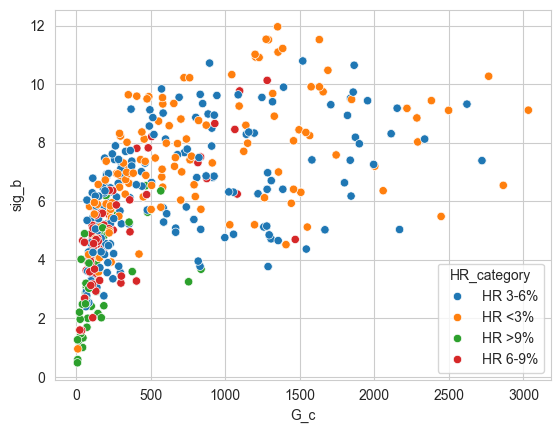

In [88]:
#scatterplot of v and sig_b
sns.scatterplot(data=df_merged, x='G_c', y='sig_b', hue='HR_category')


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

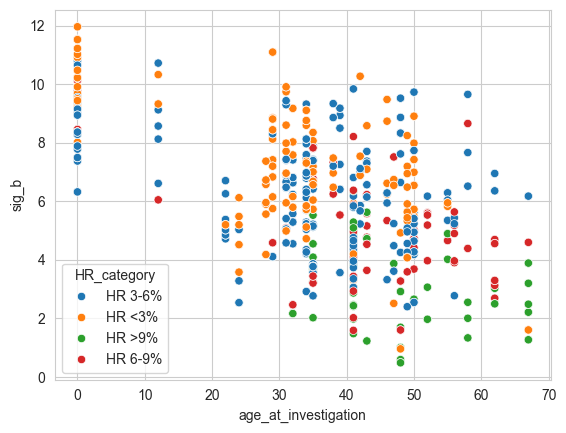

In [89]:

#scatterplot of age_at_investigation and sig_b
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR_category')

In [92]:
df_final.to_csv(working_dir.joinpath('Dikes_Projects_Samples_Tests.csv'), index=False)

In [91]:
linear_model = skl.linear_model.LinearRegression()
linear_model.fit(df_final[['age_at_investigation']], df_final['sig_b'])
linear_model.coef_, linear_model.intercept_

ValueError: Input y contains NaN.

<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

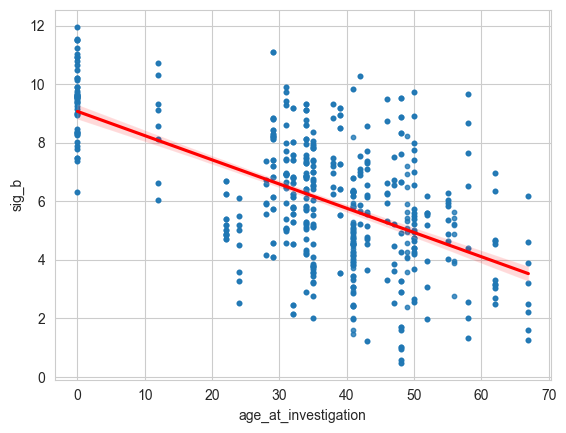

In [90]:
sns.regplot(data=df_final, x='age_at_investigation', y='sig_b', scatter_kws={'s':10}, line_kws={'color':'red'})

In [ ]:
#make a random test dataframe of 10 rows with 4 numerical columns and 1 categorical column

#generate the data
data = {
    'num1': numpy.random.rand(10),
    'num2': numpy.random.rand(10),
    'num3': numpy.random.rand(10),
    'num4': numpy.random.rand(10),
    'category': numpy.random.choice(['A', 'B'], size=10)
}
df_test = pd.DataFrame(data)

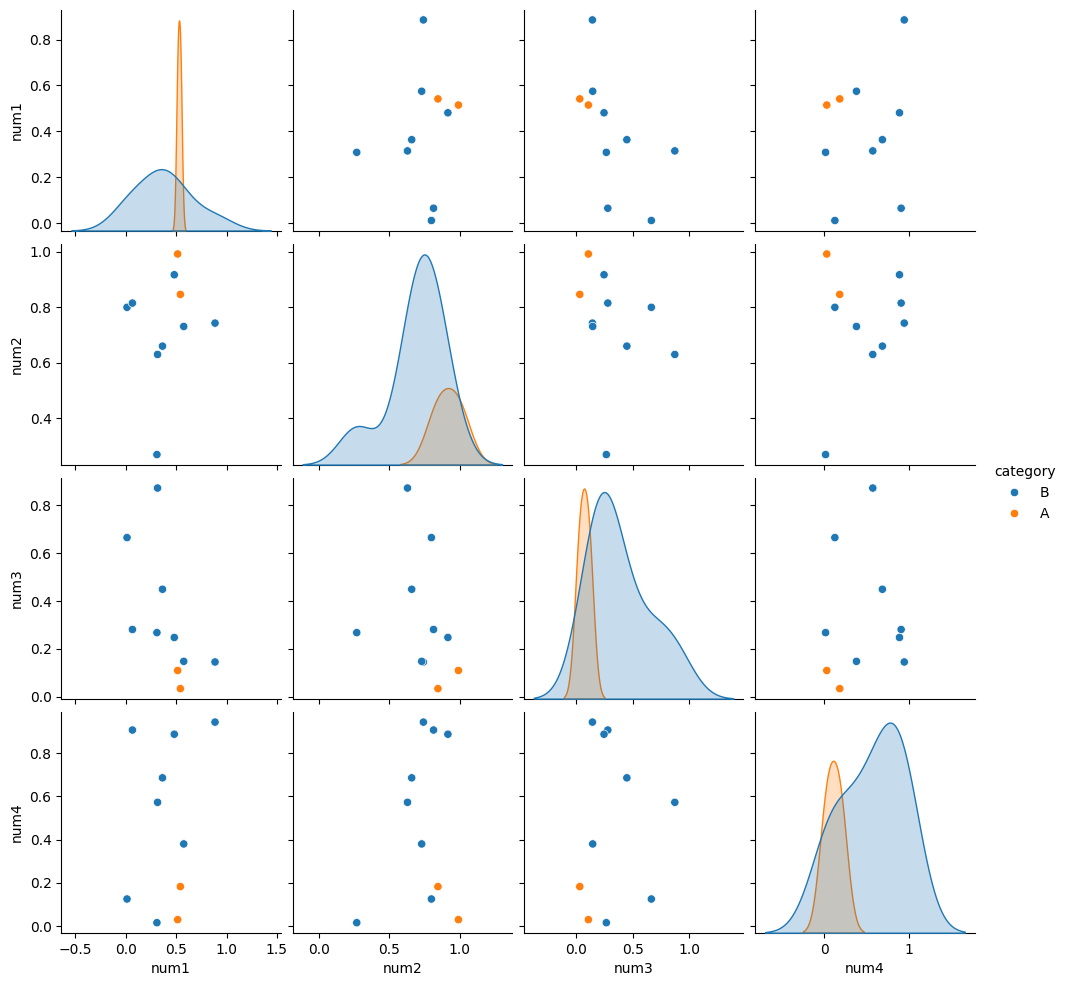

In [ ]:
sns.pairplot(df_test,hue='category')